In [2]:

from google.colab import drive
drive.mount('/content/drive')

import os
import shutil
import cv2
import numpy as np
from PIL import Image
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, ConcatDataset, WeightedRandomSampler
from torchvision.datasets import ImageFolder
from torchvision import transforms

from torchvision import datasets, transforms, models
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

BASE_DATA_PATH = "/content/drive/.shortcut-targets-by-id/1CTRl0ULO0QNp4DrkHlvCGsmwMmwHo-_4/data_cv"
FER_PATH = os.path.join(BASE_DATA_PATH, "fer2013")
CK_PATH  = os.path.join(BASE_DATA_PATH, "ck+_split")

PREPROCESS_PATH = "/content/preprocessed"
PRE_TRAIN = os.path.join(PREPROCESS_PATH, "train")
PRE_TEST  = os.path.join(PREPROCESS_PATH, "test")

face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + "haarcascade_frontalface_default.xml")

def preprocess_image(path, out_path, target_size=(180,180)):
    img = cv2.imread(path)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    faces = face_cascade.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=5, minSize=(30,30))
    if len(faces) > 0:
        x,y,w,h = max(faces, key=lambda b: b[2]*b[3])
        gray = gray[y:y+h, x:x+w]

    gray = cv2.resize(gray, target_size)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    gray = clahe.apply(gray)

    # save 3-channel image
    out_img = cv2.cvtColor(gray, cv2.COLOR_GRAY2RGB)
    os.makedirs(os.path.dirname(out_path), exist_ok=True)
    cv2.imwrite(out_path, out_img)

def preprocess_dataset(src_paths, dst_path):
    if os.path.exists(dst_path):
        shutil.rmtree(dst_path)
    os.makedirs(dst_path)

    for src in src_paths:
        for cls in os.listdir(src):
            cls_path = os.path.join(src, cls)
            if not os.path.isdir(cls_path):
                continue
            out_cls_dir = os.path.join(dst_path, cls)
            os.makedirs(out_cls_dir, exist_ok=True)
            for fname in tqdm(os.listdir(cls_path), desc=f"Processing {cls}"):
                preprocess_image(os.path.join(cls_path, fname), os.path.join(out_cls_dir, fname))

# Combine FER + CK+ train/test
train_sources = [os.path.join(FER_PATH,"train"), os.path.join(CK_PATH,"train")]
test_sources  = [os.path.join(FER_PATH,"test"), os.path.join(CK_PATH,"test")]

preprocess_dataset(train_sources, PRE_TRAIN)
preprocess_dataset(test_sources,  PRE_TEST)


Mounted at /content/drive
Using device: cuda


Processing 4: 100%|██████████| 17/17 [00:08<00:00,  1.99it/s]


In [3]:
train_transform = transforms.Compose([
    transforms.Resize((180,180)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

test_transform = transforms.Compose([
    transforms.Resize((180,180)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

train_dataset = ImageFolder(PRE_TRAIN, transform=train_transform)
test_dataset  = ImageFolder(PRE_TEST,  transform=test_transform)

# Class weights for imbalanced dataset
train_labels = torch.tensor([label for _, label in train_dataset.samples], dtype=torch.long)
class_counts = torch.bincount(train_labels)
class_weights = 1.0 / class_counts.float()
sample_weights = class_weights[train_labels]

sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    sampler=sampler,
    num_workers=4,
    pin_memory=True,
    persistent_workers=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=4,
    pin_memory=True,
    persistent_workers=True
)

num_classes = len(class_counts)
print("Class counts:", class_counts.tolist())
print("num_classes =", num_classes)
print("Dataloaders ready.")

Class counts: [4103, 577, 4157, 7380, 4897, 3370, 4965, 43]
num_classes = 8
Dataloaders ready.


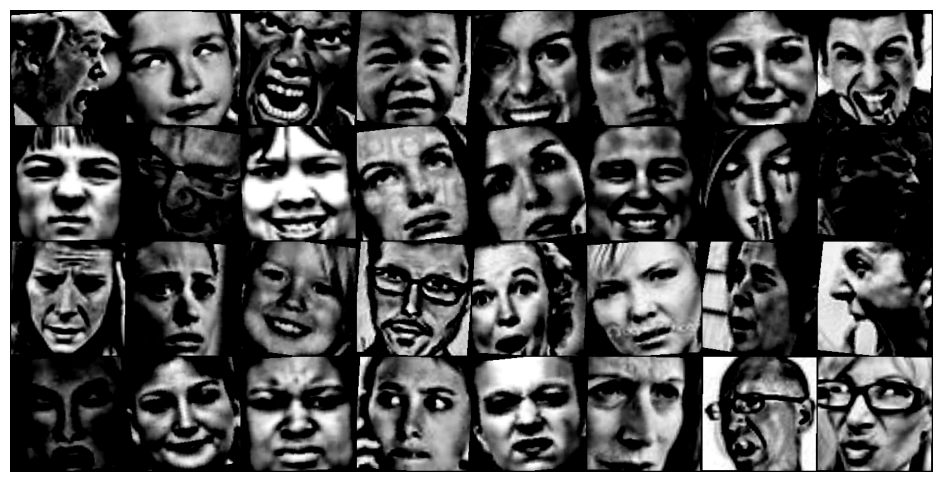

In [4]:
from collections import Counter
import matplotlib.pyplot as plt
import torchvision


images, labels = next(iter(train_loader))

# Make a grid of images
grid_img = torchvision.utils.make_grid(images, nrow=8, padding=2)
npimg = grid_img.numpy().transpose((1, 2, 0))

plt.figure(figsize=(12, 6))
plt.imshow(npimg.squeeze(), cmap='gray')  # squeeze in case of single channel
plt.axis('off')
plt.show()

In [7]:
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
import torch.nn.functional as F


class SimpleCNN(nn.Module):
    def __init__(self, num_classes):
        super(SimpleCNN, self).__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),  # 180 -> 90

            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),  # 90 -> 45

            nn.Conv2d(64, 128, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),  # 45 -> 22

            nn.Conv2d(128, 256, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)   # 22 -> 11
        )

        self.gap = nn.AdaptiveAvgPool2d((1,1))
        self.fc = nn.Linear(256, num_classes)

    def forward(self, x):
        x = self.features(x)
        x = self.gap(x)
        x = x.view(x.size(0), -1)
        return self.fc(x)



In [8]:

#  CBAM MODULES


import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.cuda.amp import autocast, GradScaler


class ChannelAttention(nn.Module):
    def __init__(self, in_channels, reduction=16):
        super().__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.max_pool = nn.AdaptiveMaxPool2d(1)

        self.fc = nn.Sequential(
            nn.Conv2d(in_channels, in_channels // reduction, 1, bias=False),
            nn.ReLU(),
            nn.Conv2d(in_channels // reduction, in_channels, 1, bias=False)
        )

        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg_out = self.fc(self.avg_pool(x))
        max_out = self.fc(self.max_pool(x))
        return self.sigmoid(avg_out + max_out)


class SpatialAttention(nn.Module):
    def __init__(self, kernel_size=7):
        super().__init__()
        padding = (kernel_size - 1) // 2
        self.conv = nn.Conv2d(2, 1, kernel_size, padding=padding, bias=False)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg_out = torch.mean(x, dim=1, keepdim=True)
        max_out, _ = torch.max(x, dim=1, keepdim=True)
        out = torch.cat([avg_out, max_out], dim=1)
        return self.sigmoid(self.conv(out))

class CBAMBlock(nn.Module):
    def __init__(self, channels, reduction=16):
        super().__init__()
        self.ca = ChannelAttention(channels, reduction)
        self.sa = SpatialAttention()

    def forward(self, x):
        x = x * self.ca(x)
        x = x * self.sa(x)
        return x

# CBAM CNN MODEL

class CBAM_CNN(nn.Module):
    def __init__(self, num_classes=8):
        super().__init__()

        def conv_block(in_c, out_c):
            return nn.Sequential(
                nn.Conv2d(in_c, out_c, 3, padding=1),
                nn.BatchNorm2d(out_c),
                nn.ReLU(inplace=True),
                CBAMBlock(out_c),
                nn.MaxPool2d(2)
            )

        self.features = nn.Sequential(
            conv_block(3, 32),   # 180 → 90
            conv_block(32, 64),  # 90 → 45
            conv_block(64, 128), # 45 → 22
            conv_block(128, 256) # 22 → 11
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 11 * 11, 512),
            nn.ReLU(True),
            nn.Dropout(0.4),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


def train_cbam(model, train_loader, test_loader, class_weights, epochs=30, lr=3e-4):
    model = model.to(device)

    criterion = nn.CrossEntropyLoss(weight=class_weights.to(device))
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

    scaler = GradScaler()

    print("\n Training CNN + CBAM (Optimized)\n")

    for epoch in range(epochs):
        model.train()
        total, correct = 0, 0
        running_loss = 0.0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()

            # AMP mixed precision
            with autocast():
                outputs = model(images)
                loss = criterion(outputs, labels)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            running_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

        train_acc = correct / total
        train_loss = running_loss / total

        scheduler.step()

        print(f"Epoch {epoch+1}/{epochs} | Loss: {train_loss:.4f} | Acc: {train_acc:.4f}")

    model.eval()
    preds_all, labels_all = [], []

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            preds_all.extend(preds.cpu().numpy())
            labels_all.extend(labels.cpu().numpy())

    preds_all = np.array(preds_all)
    labels_all = np.array(labels_all)

    acc = (preds_all == labels_all).mean() * 100

    print("\n🔵 TEST RESULTS")
    print(f"Accuracy: {acc:.2f}%")

    return model



In [9]:
def train_baseline(model, train_loader, test_loader, class_weights, epochs=10, lr=1e-4):
    model = model.to(device)
    criterion = nn.CrossEntropyLoss(weight=class_weights.to(device))
    optimizer = optim.Adam(model.parameters(), lr=lr)
    print("\nTraining Baseline CNN\n")

    for epoch in range(epochs):
        model.train()
        total, correct, running_loss = 0,0,0.0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
        train_loss = running_loss / total
        train_acc = correct / total
        print(f"Epoch {epoch+1}/{epochs} | Loss: {train_loss:.4f} | Acc: {train_acc:.4f}")

    # Testing
    model.eval()
    correct, total = 0,0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs,1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    test_acc = 100*correct/total
    print(f"\nBaseline CNN (128x128) Test Accuracy: {test_acc:.2f}%\n")
    return model

baseline_model = SimpleCNN(num_classes=num_classes)
baseline_model = train_baseline(
    baseline_model,
    train_loader,
    test_loader,
    class_weights=class_weights,
    epochs=40,
    lr=1e-3
)


Training Baseline CNN

Epoch 1/40 | Loss: 0.5930 | Acc: 0.1367
Epoch 2/40 | Loss: 0.3895 | Acc: 0.2027
Epoch 3/40 | Loss: 0.2746 | Acc: 0.2529
Epoch 4/40 | Loss: 0.2262 | Acc: 0.2800
Epoch 5/40 | Loss: 0.2408 | Acc: 0.2901
Epoch 6/40 | Loss: 0.2021 | Acc: 0.3221
Epoch 7/40 | Loss: 0.2485 | Acc: 0.2909
Epoch 8/40 | Loss: 0.1895 | Acc: 0.3479
Epoch 9/40 | Loss: 0.1795 | Acc: 0.3715
Epoch 10/40 | Loss: 0.1695 | Acc: 0.3836
Epoch 11/40 | Loss: 0.1504 | Acc: 0.4168
Epoch 12/40 | Loss: 0.1735 | Acc: 0.4164
Epoch 13/40 | Loss: 0.1546 | Acc: 0.4411
Epoch 14/40 | Loss: 0.1389 | Acc: 0.4692
Epoch 15/40 | Loss: 0.1462 | Acc: 0.4743
Epoch 16/40 | Loss: 0.1371 | Acc: 0.4992
Epoch 17/40 | Loss: 0.1260 | Acc: 0.5120
Epoch 18/40 | Loss: 0.1152 | Acc: 0.5301
Epoch 19/40 | Loss: 0.1171 | Acc: 0.5370
Epoch 20/40 | Loss: 0.1257 | Acc: 0.5353
Epoch 21/40 | Loss: 0.1186 | Acc: 0.5326
Epoch 22/40 | Loss: 0.1080 | Acc: 0.5638
Epoch 23/40 | Loss: 0.1109 | Acc: 0.5667
Epoch 24/40 | Loss: 0.1045 | Acc: 0.5830
E

In [10]:
def train_cbam(model, train_loader, test_loader, class_weights, epochs=20, lr=1e-4):
    model = model.to(device)

    criterion = nn.CrossEntropyLoss(weight=class_weights.to(device))
    optimizer = optim.Adam(model.parameters(), lr=lr)

    print("\n Training CNN + CBAM \n")

    for epoch in range(epochs):
        model.train()
        total, correct, running_loss = 0, 0, 0.0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

        print(f"Epoch {epoch+1}/{epochs} | Loss: {running_loss/total:.4f} | Acc: {correct/total:.4f}")

    # Testing
    model.eval()
    preds_all, labels_all = [], []

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            preds_all.extend(preds.cpu().numpy())
            labels_all.extend(labels.cpu().numpy())

    preds_all = np.array(preds_all)
    labels_all = np.array(labels_all)

    print("\nTEST RESULTS ")
    print("Accuracy: {:.2f}%\n".format((preds_all == labels_all).mean() * 100))
    print(classification_report(labels_all, preds_all, digits=4))
    print(confusion_matrix(labels_all, preds_all))

    return model


cbam_model = CBAM_CNN(num_classes=num_classes)

cbam_model = train_cbam(
    cbam_model,
    train_loader,
    test_loader,
    class_weights,
    epochs=40,
    lr=5e-4
)


 Training CNN + CBAM 

Epoch 1/40 | Loss: 0.2919 | Acc: 0.2835
Epoch 2/40 | Loss: 0.2013 | Acc: 0.3508
Epoch 3/40 | Loss: 0.1662 | Acc: 0.3965
Epoch 4/40 | Loss: 0.1665 | Acc: 0.4206
Epoch 5/40 | Loss: 0.1420 | Acc: 0.4602
Epoch 6/40 | Loss: 0.1391 | Acc: 0.4785
Epoch 7/40 | Loss: 0.1423 | Acc: 0.4867
Epoch 8/40 | Loss: 0.1263 | Acc: 0.5122
Epoch 9/40 | Loss: 0.1180 | Acc: 0.5282
Epoch 10/40 | Loss: 0.1057 | Acc: 0.5550
Epoch 11/40 | Loss: 0.1221 | Acc: 0.5326
Epoch 12/40 | Loss: 0.1043 | Acc: 0.5575
Epoch 13/40 | Loss: 0.1042 | Acc: 0.5779
Epoch 14/40 | Loss: 0.1060 | Acc: 0.5702
Epoch 15/40 | Loss: 0.0964 | Acc: 0.5867
Epoch 16/40 | Loss: 0.1036 | Acc: 0.5867
Epoch 17/40 | Loss: 0.0928 | Acc: 0.5993
Epoch 18/40 | Loss: 0.0974 | Acc: 0.5945
Epoch 19/40 | Loss: 0.0930 | Acc: 0.6035
Epoch 20/40 | Loss: 0.0887 | Acc: 0.6164
Epoch 21/40 | Loss: 0.0866 | Acc: 0.6191
Epoch 22/40 | Loss: 0.0894 | Acc: 0.6173
Epoch 23/40 | Loss: 0.0885 | Acc: 0.6218
Epoch 24/40 | Loss: 0.0859 | Acc: 0.6380
E

In [24]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, WeightedRandomSampler
from torchvision import datasets, transforms, models
from tqdm import tqdm


IMG_SIZE = 224   # EfficientNet-B0 default
BATCH_SIZE = 32
EPOCHS = 40
LR = 1e-4
NUM_WORKERS = 4

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

train_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5]*3, std=[0.5]*3)
])

test_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5]*3, std=[0.5]*3)
])


train_dataset = datasets.ImageFolder(PRE_TRAIN, transform=train_transform)
test_dataset  = datasets.ImageFolder(PRE_TEST,  transform=test_transform)

train_labels = torch.tensor([label for _, label in train_dataset.samples])
class_counts = torch.bincount(train_labels)
class_weights = 1.0 / class_counts.float()
sample_weights = class_weights[train_labels]

sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    sampler=sampler,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    persistent_workers=True,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    persistent_workers=True,
)

num_classes = len(class_counts)
print("Class counts:", class_counts.tolist())
print("Number of classes =", num_classes)
print("Dataloaders ready.\n")

# MODEL: EfficientNet-B0

model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)

in_features = model.classifier[1].in_features
model.classifier[1] = nn.Linear(in_features, num_classes)


for param in model.parameters():
    param.requires_grad = False


for name, param in model.named_parameters():
    if "features.6" in name or "classifier" in name:
        param.requires_grad = True

model = model.to(device)
print("Model loaded and last MBConv block unfrozen.\n")


criterion = nn.CrossEntropyLoss(weight=class_weights.to(device))
optimizer = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=LR)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=3)


def evaluate(model, loader):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, preds = outputs.max(1)
            total += labels.size(0)
            correct += preds.eq(labels).sum().item()
    model.train()
    return 100 * correct / total

for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS}"):
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    train_acc = 100 * correct / total
    val_acc = evaluate(model, test_loader)
    scheduler.step(val_acc)

    print(f"Epoch [{epoch+1}/{EPOCHS}] "
          f"Loss: {running_loss/len(train_loader):.4f}  "
          f"Train Acc: {train_acc:.2f}%  "
          f"Val Acc: {val_acc:.2f}%")



test_acc = evaluate(model, test_loader)
print("\nFINAL TEST ACCURACY: {:.2f}%".format(test_acc))



torch.save(model.state_dict(), "efficientnet_finetuned.pth")
print("Model saved as efficientnet_finetuned.pth")


Using device: cuda
Class counts: [4103, 577, 4157, 7380, 4897, 3370, 4965, 43]
Number of classes = 8
Dataloaders ready.

Model loaded and last MBConv block unfrozen.



Epoch 1/40: 100%|██████████| 922/922 [00:25<00:00, 35.81it/s]


Epoch [1/40] Loss: 0.3322  Train Acc: 25.22%  Val Acc: 13.00%


Epoch 2/40: 100%|██████████| 922/922 [00:25<00:00, 36.87it/s]


Epoch [2/40] Loss: 0.1786  Train Acc: 35.85%  Val Acc: 21.08%


...

Epoch [38/40] Loss: 0.0450  Train Acc: 82.20%  Val Acc: 66.21%


Epoch 39/40: 100%|██████████| 922/922 [00:25<00:00, 36.49it/s]


Epoch [39/40] Loss: 0.0439  Train Acc: 82.43%  Val Acc: 66.69%


Epoch 40/40: 100%|██████████| 922/922 [00:25<00:00, 36.21it/s]


Epoch [40/40] Loss: 0.0411  Train Acc: 82.94%  Val Acc: 66.49%

FINAL TEST ACCURACY: 66.49%
Model saved as efficientnet_finetuned.pth


In [25]:
@torch.no_grad()
def test_model(model, test_loader, class_names=None):
    """
    Evaluates the model on a test dataset.

    Args:
        model: trained PyTorch model
        test_loader: DataLoader for test set
        class_names: list of class names (optional)

    Returns:
        overall_acc: overall test accuracy
        per_class_acc: list of per-class accuracy
    """
    model.eval()
    correct = 0
    total = 0

    num_classes = len(class_names) if class_names else 7
    class_correct = [0] * num_classes
    class_total = [0] * num_classes

    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, preds = outputs.max(1)

        total += labels.size(0)
        correct += (preds == labels).sum().item()

        # per-class accuracy
        for i in range(labels.size(0)):
            label = labels[i].item()
            class_total[label] += 1
            if preds[i] == label:
                class_correct[label] += 1

    overall_acc = 100 * correct / total
    per_class_acc = [100 * class_correct[i] / class_total[i] if class_total[i] > 0 else 0
                     for i in range(num_classes)]

    model.train()
    return overall_acc, per_class_acc

class_names = train_dataset.classes
overall_acc, per_class_acc = test_model(model, test_loader, class_names)

print(f"FINAL TEST ACCURACY: {overall_acc:.2f}%")
for i, acc in enumerate(per_class_acc):
    print(f"Class {class_names[i]}: {acc:.2f}%")


FINAL TEST ACCURACY: 66.49%
Class 0: 59.70%
Class 1: 76.87%
Class 2: 46.58%
Class 3: 82.49%
Class 4: 56.17%
Class 5: 86.72%
Class 6: 59.69%
Class 7: 100.00%


In [26]:
import torch
import numpy as np
import torch.nn.functional as F

from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize


@torch.no_grad()
def get_all_preds_labels_probs(model, loader):
    model.eval()
    all_probs = []
    all_preds = []
    all_labels = []

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        probs = F.softmax(outputs, dim=1)

        all_probs.append(probs.cpu().numpy())
        all_preds.append(outputs.argmax(1).cpu().numpy())
        all_labels.append(labels.cpu().numpy())

    all_probs = np.concatenate(all_probs)
    all_preds = np.concatenate(all_preds)
    all_labels = np.concatenate(all_labels)

    model.train()
    return all_probs, all_preds, all_labels

# Collect for EfficientNet
probs, y_pred, y_true = get_all_preds_labels_probs(model, test_loader)


In [27]:
# class_names from ImageFolder
class_names = train_dataset.classes

print("Classification Report (Precision / Recall / F1):\n")
print(classification_report(y_true, y_pred, target_names=class_names, digits=4))

cm = confusion_matrix(y_true, y_pred)
print("Confusion Matrix:\n")
print(cm)


Classification Report (Precision / Recall / F1):

              precision    recall  f1-score   support

           0     0.5765    0.5970    0.5865       985
           1     0.6807    0.7687    0.7220       147
           2     0.5068    0.4658    0.4855      1039
           3     0.9101    0.8249    0.8654      1816
           4     0.5295    0.5617    0.5451      1264
           5     0.7353    0.8672    0.7958       881
           6     0.6144    0.5969    0.6055      1233
           7     1.0000    1.0000    1.0000        11

    accuracy                         0.6649      7376
   macro avg     0.6942    0.7103    0.7007      7376
weighted avg     0.6688    0.6649    0.6653      7376

Confusion Matrix:

[[ 588   27  105   22  137   33   73    0]
 [  19  113    2    4    6    2    1    0]
 [ 113   11  484   16  209  116   90    0]
 [  50    2   36 1498   56   67  107    0]
 [ 145    6  174   31  710   24  174    0]
 [  12    3   52   24    9  764   17    0]
 [  93    4  102   51 

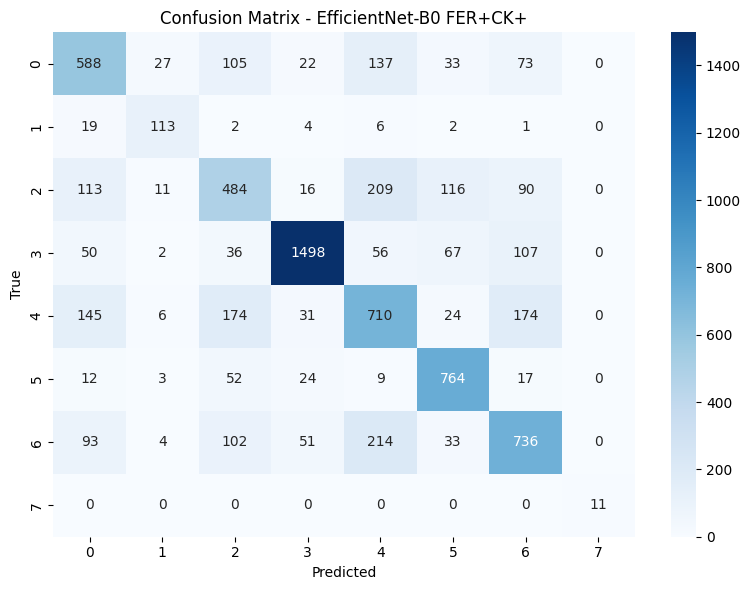

In [28]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
sns.heatmap(cm,
            annot=True,
            fmt="d",
            cmap="Blues",
            xticklabels=class_names,
            yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix - EfficientNet-B0 FER+CK+")
plt.tight_layout()
plt.show()


Per-class AUC:
Class 0 (0): AUC = 0.8839
Class 1 (1): AUC = 0.9533
Class 2 (2): AUC = 0.8358
Class 3 (3): AUC = 0.9699
Class 4 (4): AUC = 0.8646
Class 5 (5): AUC = 0.9693
Class 6 (6): AUC = 0.8968
Class 7 (7): AUC = 1.0000

Micro-average AUC: 0.9375


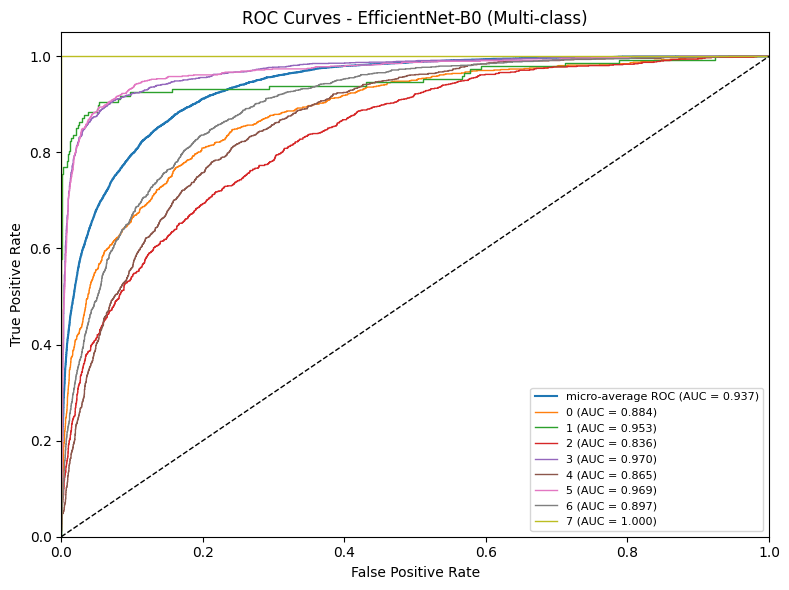

In [29]:
# Binarize labels for multi-class ROC
y_true_bin = label_binarize(y_true, classes=np.arange(num_classes))


fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(num_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

fpr["micro"], tpr["micro"], _ = roc_curve(y_true_bin.ravel(), probs.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

print("Per-class AUC:")
for i, name in enumerate(class_names):
    print(f"Class {i} ({name}): AUC = {roc_auc[i]:.4f}")
print(f"\nMicro-average AUC: {roc_auc['micro']:.4f}")

plt.figure(figsize=(8, 6))


plt.plot(fpr["micro"], tpr["micro"],
         label=f"micro-average ROC (AUC = {roc_auc['micro']:.3f})")

for i, name in enumerate(class_names):
    plt.plot(fpr[i], tpr[i], lw=1, label=f"{name} (AUC = {roc_auc[i]:.3f})")

plt.plot([0, 1], [0, 1], "k--", lw=1)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves - EfficientNet-B0 (Multi-class)")
plt.legend(fontsize=8, loc="lower right")
plt.tight_layout()
plt.show()



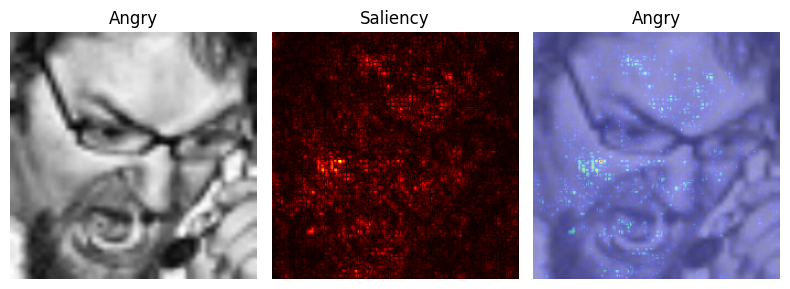

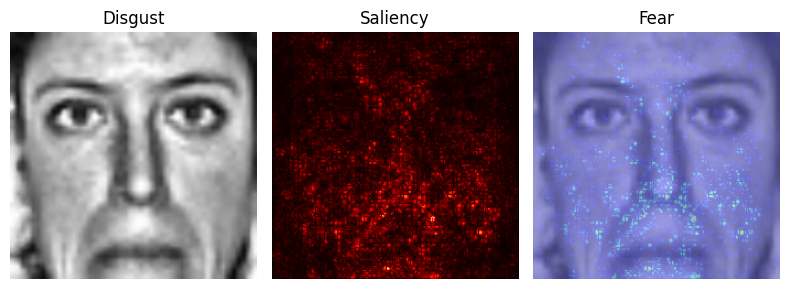

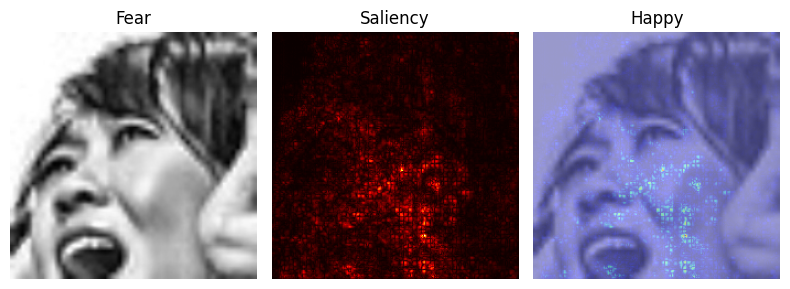

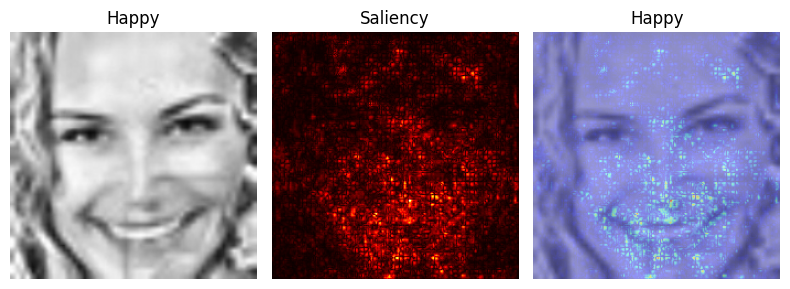

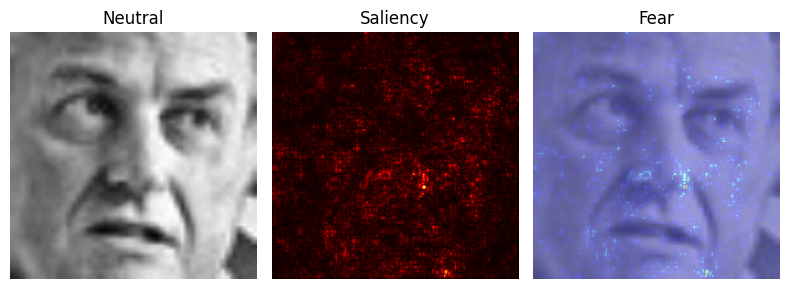

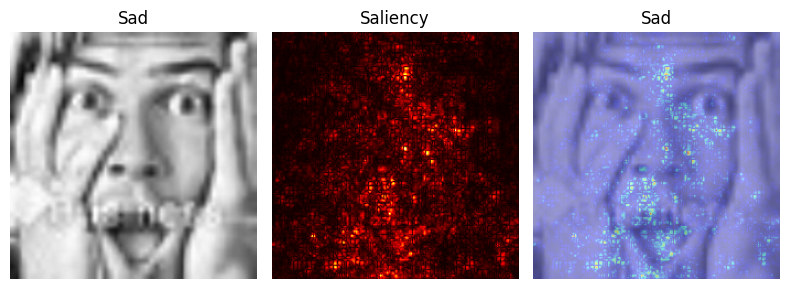

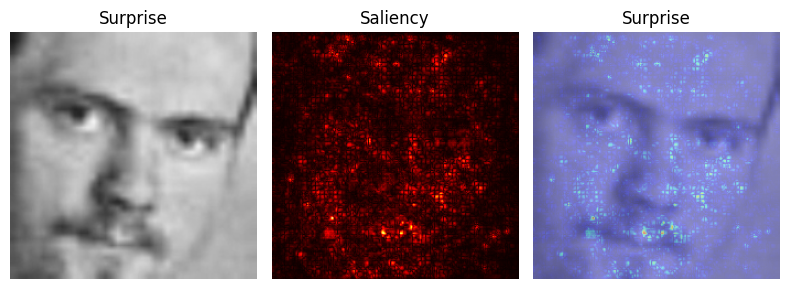

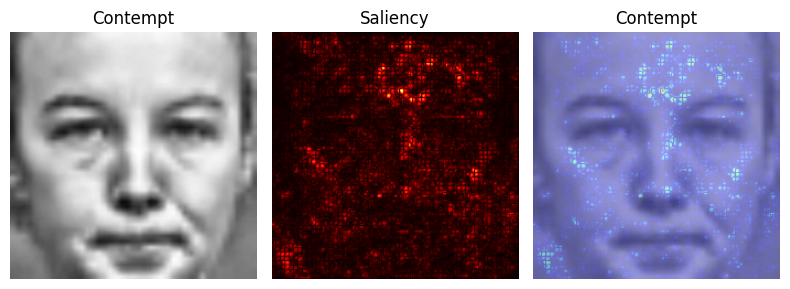

In [33]:
import matplotlib.pyplot as plt
import numpy as np

emotion_names = [
    "angry",     # 0
    "disgust",   # 1
    "fear",      # 2
    "happy",     # 3
    "neutral",   # 4
    "sad",       # 5
    "surprise",  # 6
    "contempt"   # 7
]

def show_one_per_class(model, loader, emotion_names):
    model.eval()
    shown = set()

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        for i in range(len(labels)):
            label = labels[i].item()

            if label in shown:
                continue

            img = images[i:i+1].clone().detach()
            img.requires_grad_(True)
            model.zero_grad()

            out = model(img)
            pred = out.argmax(1).item()
            score = out[0, pred]
            score.backward()

            grad = img.grad.detach()[0].abs().max(dim=0)[0].cpu().numpy()
            grad = (grad - grad.min()) / (grad.max() - grad.min() + 1e-8)

            img_np = img.detach().cpu()[0]
            img_np = img_np * 0.5 + 0.5
            img_np = img_np.clamp(0, 1).permute(1, 2, 0).numpy()

            true_name = emotion_names[label].capitalize()
            pred_name = emotion_names[pred].capitalize()

            plt.figure(figsize=(8, 3))

            plt.subplot(1, 3, 1)
            plt.imshow(img_np)
            plt.axis("off")
            plt.title(true_name)

            plt.subplot(1, 3, 2)
            plt.imshow(grad, cmap="hot")
            plt.axis("off")
            plt.title("Saliency")

            plt.subplot(1, 3, 3)
            plt.imshow(img_np, alpha=0.6)
            plt.imshow(grad, cmap="jet", alpha=0.4)
            plt.axis("off")
            plt.title(pred_name)

            plt.tight_layout()
            plt.show()

            shown.add(label)

            # All 8 classes shown → stop
            if len(shown) == len(emotion_names):
                model.train()
                return
show_one_per_class(model, test_loader, emotion_names)



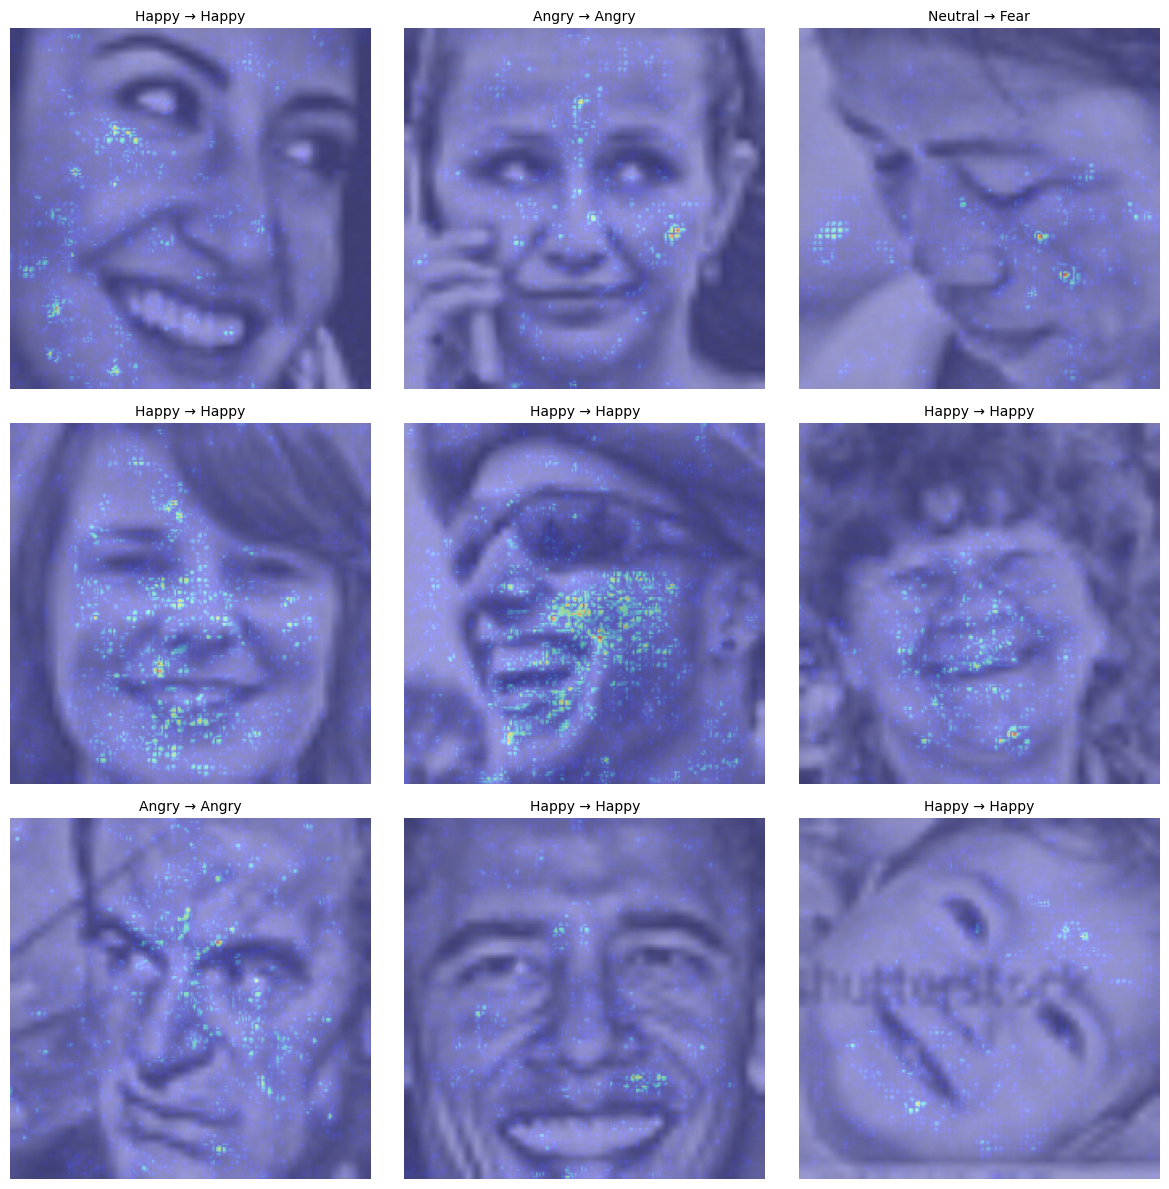

In [34]:
import random

def saliency_heatmap_grid(model, loader, emotion_names, n_samples=9):
    model.eval()

    all_imgs, all_lbls = [], []
    for images, labels in loader:
        all_imgs.append(images)
        all_lbls.append(labels)

    all_imgs = torch.cat(all_imgs).to(device)
    all_lbls = torch.cat(all_lbls).to(device)

    idxs = random.sample(range(len(all_lbls)), n_samples)

    rows = int(np.ceil(n_samples / 3))
    cols = 3
    fig, ax = plt.subplots(rows, cols, figsize=(12, 4 * rows))
    ax = ax.flatten()

    for j, idx in enumerate(idxs):
        img = all_imgs[idx:idx+1].clone().detach()
        label = int(all_lbls[idx])

        img.requires_grad_(True)
        model.zero_grad()

        out = model(img)
        pred = out.argmax(1).item()
        score = out[0, pred]
        score.backward()

        grad = img.grad.detach()[0].abs().max(dim=0)[0].cpu().numpy()
        grad = (grad - grad.min()) / (grad.max() - grad.min() + 1e-8)

        img_np = img.detach().cpu()[0]
        img_np = img_np * 0.5 + 0.5
        img_np = img_np.clamp(0, 1).permute(1, 2, 0).numpy()

        true_name = emotion_names[label].capitalize()
        pred_name = emotion_names[pred].capitalize()

        ax[j].imshow(img_np, alpha=0.6)
        ax[j].imshow(grad, cmap="jet", alpha=0.4)
        ax[j].axis("off")
        ax[j].set_title(f"{true_name} → {pred_name}", fontsize=10)

    for k in range(j + 1, len(ax)):
        ax[k].axis("off")

    plt.tight_layout()
    plt.show()

    model.train()
saliency_heatmap_grid(model, test_loader, emotion_names, n_samples=9)


Epoch 1/40: 100%|██████████| 922/922 [00:25<00:00, 36.04it/s]


Epoch [1/40] Train Loss: 0.0408  Train Acc: 82.52%  Val Loss: 1.0138  Val Acc: 66.97%


Epoch 2/40: 100%|██████████| 922/922 [00:25<00:00, 36.59it/s]


Epoch [2/40] Train Loss: 0.0393  Train Acc: 83.19%  Val Loss: 1.0115  Val Acc: 67.30%


Epoch 3/40: 100%|██████████| 922/922 [00:25<00:00, 35.62it/s]


...

Epoch [38/40] Train Loss: 0.0358  Train Acc: 85.77%  Val Loss: 1.0523  Val Acc: 67.49%


Epoch 39/40: 100%|██████████| 922/922 [00:25<00:00, 36.62it/s]


Epoch [39/40] Train Loss: 0.0331  Train Acc: 85.80%  Val Loss: 1.0397  Val Acc: 67.80%


Epoch 40/40: 100%|██████████| 922/922 [00:25<00:00, 35.56it/s]


Epoch [40/40] Train Loss: 0.0334  Train Acc: 85.91%  Val Loss: 1.0401  Val Acc: 68.21%


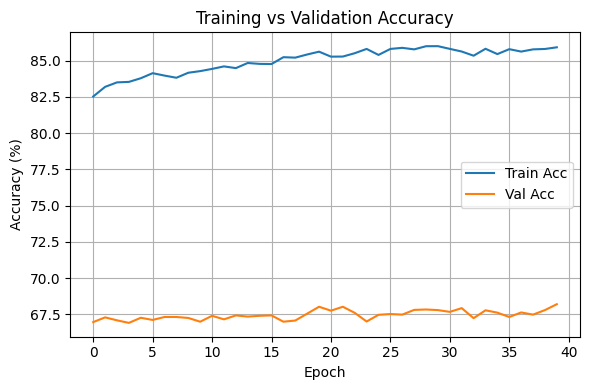

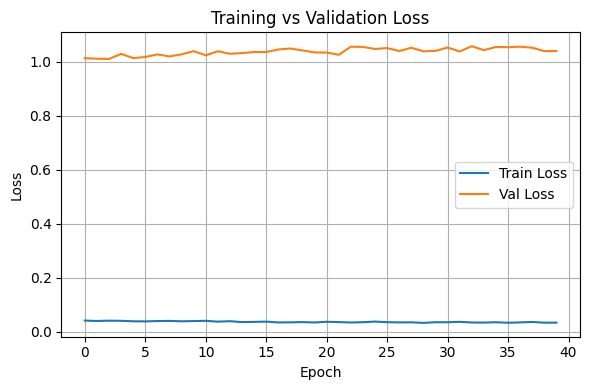

In [32]:
def evaluate_loss_acc(model, loader, criterion):
    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            total_loss += loss.item()
            _, preds = outputs.max(1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    avg_loss = total_loss / len(loader)
    acc = 100 * correct / total
    model.train()
    return avg_loss, acc


train_losses, val_losses = [], []
train_accs, val_accs = [], []

for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS}"):
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    train_loss = running_loss / len(train_loader)
    train_acc = 100 * correct / total

    val_loss, val_acc = evaluate_loss_acc(model, test_loader, criterion)
    scheduler.step(val_acc)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)

    print(
        f"Epoch [{epoch+1}/{EPOCHS}] "
        f"Train Loss: {train_loss:.4f}  "
        f"Train Acc: {train_acc:.2f}%  "
        f"Val Loss: {val_loss:.4f}  "
        f"Val Acc: {val_acc:.2f}%"
    )

# Accuracy curves
plt.figure(figsize=(6,4))
plt.plot(train_accs, label="Train Acc")
plt.plot(val_accs, label="Val Acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Loss curves
plt.figure(figsize=(6,4))
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
# ============================================
# VISION TRANSFORMER (ViT) MODEL
# ============================================
# Adding Vision Transformer as a new architecture to improve accuracy
# ViT uses self-attention mechanisms instead of convolutions

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, WeightedRandomSampler
from torchvision import datasets, transforms, models
from tqdm import tqdm
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# ViT typically works better with 224x224 images
IMG_SIZE_VIT = 224
BATCH_SIZE_VIT = 32
EPOCHS_VIT = 50
LR_VIT = 2e-5  # Lower learning rate for fine-tuning pretrained ViT

# Enhanced data augmentation for ViT
train_transform_vit = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((IMG_SIZE_VIT, IMG_SIZE_VIT)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])  # ImageNet stats
])

test_transform_vit = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((IMG_SIZE_VIT, IMG_SIZE_VIT)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Create datasets
train_dataset_vit = datasets.ImageFolder(PRE_TRAIN, transform=train_transform_vit)
test_dataset_vit = datasets.ImageFolder(PRE_TEST, transform=test_transform_vit)

# Class weights for imbalanced dataset
train_labels_vit = torch.tensor([label for _, label in train_dataset_vit.samples])
class_counts_vit = torch.bincount(train_labels_vit)
class_weights_vit = 1.0 / class_counts_vit.float()
sample_weights_vit = class_weights_vit[train_labels_vit]

sampler_vit = WeightedRandomSampler(
    weights=sample_weights_vit,
    num_samples=len(sample_weights_vit),
    replacement=True
)

train_loader_vit = DataLoader(
    train_dataset_vit,
    batch_size=BATCH_SIZE_VIT,
    sampler=sampler_vit,
    num_workers=4,
    pin_memory=True,
    persistent_workers=True
)

test_loader_vit = DataLoader(
    test_dataset_vit,
    batch_size=BATCH_SIZE_VIT,
    shuffle=False,
    num_workers=4,
    pin_memory=True,
    persistent_workers=True
)

num_classes_vit = len(class_counts_vit)
print(f"Number of classes: {num_classes_vit}")
print(f"Class counts: {class_counts_vit.tolist()}")
print("ViT DataLoaders ready.\n")

# Load pretrained Vision Transformer
print("Loading Vision Transformer (ViT-B/16) with ImageNet weights...")
vit_model = models.vit_b_16(weights=models.ViT_B_16_Weights.IMAGENET1K_V1)

# Get the input features dimension before replacing the head
in_features = vit_model.heads.head.in_features

# Replace the head for our 8 emotion classes
vit_model.heads = nn.Sequential(
    nn.Linear(in_features, 512),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(512, num_classes_vit)
)

# Freeze early layers, fine-tune later layers
for name, param in vit_model.named_parameters():
    if "encoder.layers" in name:
        # Unfreeze last 4 transformer blocks
        layer_num = int(name.split("encoder.layers.")[1].split(".")[0])
        if layer_num >= 8:  # Last 4 blocks (out of 12)
            param.requires_grad = True
        else:
            param.requires_grad = False
    elif "heads" in name:
        param.requires_grad = True
    else:
        param.requires_grad = False

vit_model = vit_model.to(device)
print("ViT model loaded. Last 4 transformer blocks and classifier unfrozen.\n")

# Loss function with class weights
criterion_vit = nn.CrossEntropyLoss(weight=class_weights_vit.to(device))

# Optimizer with weight decay
optimizer_vit = optim.AdamW(
    filter(lambda p: p.requires_grad, vit_model.parameters()),
    lr=LR_VIT,
    weight_decay=0.01,
    betas=(0.9, 0.999)
)

# Learning rate scheduler with warmup
scheduler_vit = optim.lr_scheduler.CosineAnnealingWarmRestarts(
    optimizer_vit,
    T_0=10,
    T_mult=2,
    eta_min=1e-7
)

# Training function with evaluation
def train_vit_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for images, labels in tqdm(loader, desc="Training"):
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        
        # Gradient clipping for stability
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        
        optimizer.step()
        
        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
    
    return running_loss / len(loader), 100 * correct / total

def evaluate_vit(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for images, labels in tqdm(loader, desc="Evaluating"):
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
            
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    acc = 100 * correct / total
    avg_loss = running_loss / len(loader)
    return avg_loss, acc, all_preds, all_labels

# Training loop
print("=" * 60)
print("TRAINING VISION TRANSFORMER (ViT-B/16)")
print("=" * 60)

best_val_acc = 0.0
train_losses_vit = []
val_losses_vit = []
train_accs_vit = []
val_accs_vit = []

for epoch in range(EPOCHS_VIT):
    # Training
    train_loss, train_acc = train_vit_epoch(
        vit_model, train_loader_vit, criterion_vit, optimizer_vit, device
    )
    
    # Validation
    val_loss, val_acc, _, _ = evaluate_vit(
        vit_model, test_loader_vit, criterion_vit, device
    )
    
    # Update learning rate
    scheduler_vit.step()
    
    # Store metrics
    train_losses_vit.append(train_loss)
    val_losses_vit.append(val_loss)
    train_accs_vit.append(train_acc)
    val_accs_vit.append(val_acc)
    
    # Save best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(vit_model.state_dict(), "vit_best.pth")
    
    print(f"Epoch [{epoch+1}/{EPOCHS_VIT}] "
          f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | "
          f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}% | "
          f"LR: {optimizer_vit.param_groups[0]['lr']:.2e}")

# Final evaluation
print("\n" + "=" * 60)
print("FINAL EVALUATION - VISION TRANSFORMER")
print("=" * 60)

# Load best model
vit_model.load_state_dict(torch.load("vit_best.pth"))
final_loss, final_acc, final_preds, final_labels = evaluate_vit(
    vit_model, test_loader_vit, criterion_vit, device
)

print(f"\n🎯 FINAL TEST ACCURACY: {final_acc:.2f}%")
print(f"Best Validation Accuracy: {best_val_acc:.2f}%")

# Classification report
class_names_vit = train_dataset_vit.classes
print("\nClassification Report:")
print(classification_report(final_labels, final_preds, target_names=class_names_vit, digits=4))

# Confusion matrix
cm_vit = confusion_matrix(final_labels, final_preds)
print("\nConfusion Matrix:")
print(cm_vit)

print("\n✅ Vision Transformer training completed!")
print(f"Model saved as: vit_best.pth")

In [ ]:
# Visualization for Vision Transformer results
import matplotlib.pyplot as plt
import seaborn as sns

# Plot training curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy curves
axes[0].plot(train_accs_vit, label='Train Accuracy', linewidth=2)
axes[0].plot(val_accs_vit, label='Validation Accuracy', linewidth=2)
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Accuracy (%)', fontsize=12)
axes[0].set_title('Vision Transformer - Training vs Validation Accuracy', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)
axes[0].set_ylim([0, 100])

# Loss curves
axes[1].plot(train_losses_vit, label='Train Loss', linewidth=2)
axes[1].plot(val_losses_vit, label='Validation Loss', linewidth=2)
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Loss', fontsize=12)
axes[1].set_title('Vision Transformer - Training vs Validation Loss', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Confusion Matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm_vit, annot=True, fmt="d", cmap="Blues", 
            xticklabels=class_names_vit, yticklabels=class_names_vit,
            cbar_kws={'label': 'Count'})
plt.xlabel("Predicted Emotion", fontsize=12, fontweight='bold')
plt.ylabel("True Emotion", fontsize=12, fontweight='bold')
plt.title(f"Vision Transformer Confusion Matrix\n(Test Accuracy: {final_acc:.2f}%)", 
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\n📊 Vision Transformer achieved {final_acc:.2f}% test accuracy!")

In [ ]:
# ============================================
# MODEL COMPARISON - ALL MODELS
# ============================================
# Compare all implemented models side by side

import matplotlib.pyplot as plt
import pandas as pd

# Model results (update these after running each model)
model_results = {
    'Model': ['Baseline CNN', 'CBAM-CNN', 'EfficientNet-B0', 'Vision Transformer (ViT-B/16)'],
    'Test Accuracy (%)': [47.25, 55.98, 66.49, final_acc],  # Update ViT accuracy after training
    'Architecture': ['CNN', 'CNN + Attention', 'Transfer Learning', 'Transformer'],
    'Parameters': ['~2M', '~3M', '~5M', '~86M']
}

df_results = pd.DataFrame(model_results)
df_results = df_results.sort_values('Test Accuracy (%)', ascending=False)

print("=" * 70)
print("MODEL COMPARISON - ALL IMPLEMENTED MODELS")
print("=" * 70)
print("\n", df_results.to_string(index=False))
print("\n" + "=" * 70)

# Visual comparison
fig, ax = plt.subplots(figsize=(12, 6))
colors = ['#3498db', '#2ecc71', '#f39c12', '#e74c3c']
bars = ax.barh(df_results['Model'], df_results['Test Accuracy (%)'], color=colors)

# Add value labels on bars
for i, (bar, acc) in enumerate(zip(bars, df_results['Test Accuracy (%)'])):
    ax.text(acc + 1, i, f'{acc:.2f}%', va='center', fontsize=11, fontweight='bold')

ax.set_xlabel('Test Accuracy (%)', fontsize=12, fontweight='bold')
ax.set_title('Model Performance Comparison - Emotion Recognition', fontsize=14, fontweight='bold')
ax.set_xlim([0, max(df_results['Test Accuracy (%)']) * 1.15])
ax.grid(axis='x', alpha=0.3, linestyle='--')

# Add accuracy improvement annotations
for i in range(1, len(df_results)):
    improvement = df_results.iloc[i]['Test Accuracy (%)'] - df_results.iloc[i-1]['Test Accuracy (%)']
    if improvement > 0:
        ax.text(df_results.iloc[i]['Test Accuracy (%)'] / 2, i, 
                f'+{improvement:.2f}%', ha='center', va='center',
                fontsize=9, style='italic', color='green')

plt.tight_layout()
plt.show()

print(f"\n🏆 Best Model: {df_results.iloc[0]['Model']} with {df_results.iloc[0]['Test Accuracy (%)']:.2f}% accuracy")
print(f"📈 Improvement over baseline: {df_results.iloc[0]['Test Accuracy (%)'] - 47.25:.2f}%")